In [21]:
import os
from langchain_core.prompts import ChatPromptTemplate,PromptTemplate
from langgraph.graph.state import StateGraph,START,END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_groq import ChatGroq
load_dotenv()


True

In [22]:
groq_api_key=os.getenv("GROQ_API_KEY")

In [23]:
class Substate(TypedDict):
    input_text:str
    translated_text:str

In [24]:
subgraph_llm=ChatGroq(model="openai/gpt-oss-120b",temperature=0.1,api_key=groq_api_key)#qwen/qwen3-32b

In [25]:
subgraph_builder=StateGraph(Substate)

In [26]:
def translate_text(state:Substate):
    prompt = f"""
Translate the following text to Hindi.
Keep it natural and clear. Do not add extra content.

Text:
{state["input_text"]}
""".strip()
      
    translate_text=subgraph_llm.invoke(prompt).content

    return{"translated_text": translate_text}

In [27]:
subgraph_builder.add_node('translate_text',translate_text)

subgraph_builder.add_edge(START,'translate_text')
subgraph_builder.add_edge('translate_text',END)
subgraph=subgraph_builder.compile()

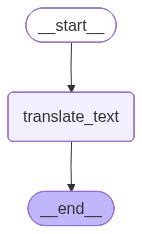

In [28]:
subgraph

In [29]:
class Parentstate(TypedDict):
    question:str
    answer_eng:str
    answer_hindi:str

In [30]:
Parentllm=ChatGroq(model="qwen/qwen3-32b",temperature=0.1,api_key=groq_api_key)

In [31]:
def generate_answer(state:Parentstate):
    prompt = f"""Answer the following question in English.
Question:
{state["question"]}
""".strip()
    answer_eng=Parentllm.invoke(prompt).content

    return{"answer_eng": answer_eng}

In [ ]:
def translate_hindi(state:Parentstate):
    subgraph_input={"input_text": state["answer_eng"]} #taking the answer from parent graph and passing it to subgraph
    subgraph_output=subgraph.invoke(subgraph_input)
    return{"answer_hindi": subgraph_output["translated_text"]} #taking the translated text from subgraph and passing it back to parent graph

In [33]:
parentbuilder=StateGraph(Parentstate)
parentbuilder.add_node('generate_answer',generate_answer)
parentbuilder.add_node('translate_hindi',translate_hindi)
parentbuilder.add_edge(START,'generate_answer')
parentbuilder.add_edge('generate_answer','translate_hindi')
parentbuilder.add_edge('translate_hindi',END)
parentgraph=parentbuilder.compile()

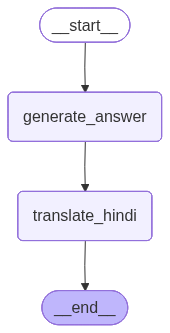

In [34]:
parentgraph

In [38]:
intail_state={"question":"what is mechanichal engineering?"}
result=parentgraph.invoke(intail_state)


In [39]:
result

{'question': 'what is mechanichal engineering?',
 'answer_eng': '<think>\nOkay, the user is asking, "What is mechanical engineering?" Let me start by recalling the basics. Mechanical engineering is a branch of engineering that deals with the design, analysis, manufacturing, and maintenance of mechanical systems. But I need to make sure I cover all the key points.\n\nFirst, I should mention that it\'s one of the oldest and broadest engineering disciplines. It involves principles of physics, mathematics, and materials science. Applications are everywhere, from small components to large systems. Maybe give examples like engines, machines, or even robotics.\n\nI should also talk about the different areas within mechanical engineering. For example, thermodynamics, fluid mechanics, mechanics of materials, and kinematics. These are core subjects. Also, mention modern aspects like CAD (Computer-Aided Design), simulation software, and manufacturing processes.\n\nIt\'s important to highlight the

In [40]:
subgraph.invoke({"input_text":"hi i am fine"})

{'input_text': 'hi i am fine', 'translated_text': 'हाय, मैं ठीक हूँ।'}